Training Multi-Output Random Forest...


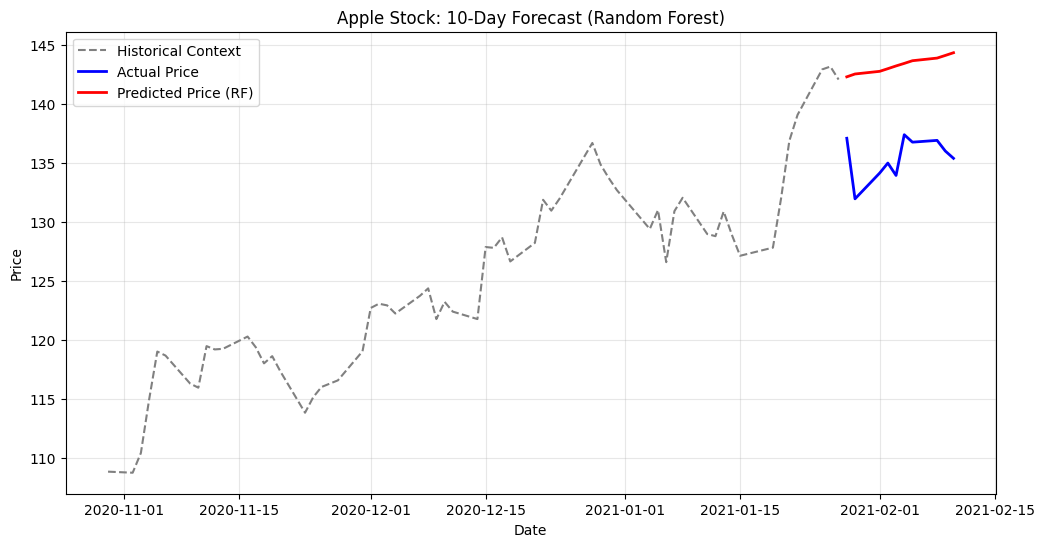


------------------------------
RMSE: 8.0060
NRMSE (Normalized by Range): 1.4744 (147.44%)
NRMSE (Normalized by Mean):  0.0591 (5.91%)
------------------------------
Directional Accuracy: 40.00%
Baseline (Always Up): 40.00%
------------------------------



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# ==========================================
# 1. DATA LOADING & FEATURE ENGINEERING
# ==========================================
title = "Apple Stock: 10-Day Forecast (Random Forest)"
data = pd.read_csv("data/AppleStock.csv")
data['date'] = pd.to_datetime(data['date'])

data['return'] = data['close'].pct_change()
data['return_mavg'] = data['return'].rolling(window=5).mean()
data['vol_change'] = data['volume'].pct_change()

data = data.dropna().reset_index(drop=True)

feature_cols = ['return', 'return_mavg', 'vol_change']
dataset = data[feature_cols].values
num_features = len(feature_cols)
window_size = 60
prediction_days = 10  # We want to predict 10 days at once

# ==========================================
# 2. DATA SPLITTING & SCALING
# ==========================================
training_data_len = int(np.ceil(len(dataset)) * 0.95)

scaler = StandardScaler()
scaler.fit(dataset[:training_data_len])

scaled_train = scaler.transform(dataset[:training_data_len])
scaled_test_source = scaler.transform(dataset[training_data_len - window_size:])

# ==========================================
# 3. MULTI-OUTPUT DATA PREPARATION
# ==========================================
X_train, y_train = [], []

# Stop early to ensure we have a full 10-day 'answer' block
for i in range(window_size, len(scaled_train) - prediction_days):
    window = scaled_train[i-window_size:i, :].flatten()
    X_train.append(window)
    # Grab the next 10 days of the 'return' column (index 0)
    y_train.append(scaled_train[i : i + prediction_days, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

# ==========================================
# 4. MODEL ARCHITECTURE 
# ==========================================
# The RF model natively handles the 10-output array we just created
model = RandomForestRegressor(
    n_estimators=50, 
    max_depth=7, 
    max_samples=0.5, 
    min_samples_leaf=5,
    random_state=42, 
    n_jobs=-1
)

print("Training Multi-Output Random Forest...")
model.fit(X_train, y_train)

# ==========================================
# 5. DIRECT 10-DAY PREDICTION (NO DRIFT LOOP)
# ==========================================
# Grab the very last 60 days of the training/source data
last_window = scaled_test_source[:window_size, :].flatten().reshape(1, -1)

# Predict all 10 days in one shot
predicted_returns_scaled = model.predict(last_window)[0] 

# ==========================================
# 6. PRICE RECONSTRUCTION & VISUALIZATION
# ==========================================
dummy_scaler = np.zeros((prediction_days, num_features))
dummy_scaler[:, 0] = predicted_returns_scaled
predictions_raw_returns = scaler.inverse_transform(dummy_scaler)[:, 0]

# Reconstruct Prices
last_actual_price = data['close'].iloc[training_data_len - 1]
reconstructed_prices = []

for ret in predictions_raw_returns:
    next_price = last_actual_price * (1 + ret)
    reconstructed_prices.append(next_price)
    last_actual_price = next_price

# Dataframe for the 10-day window
test_df_subset = data[training_data_len : training_data_len + prediction_days].copy()
test_df_subset['Predictions'] = reconstructed_prices

# --- PLOTTING ---
plt.figure(figsize=(12,6))

# 1. Historical Context 
plt.plot(data['date'].iloc[training_data_len-window_size : training_data_len], 
         data['close'].iloc[training_data_len-window_size : training_data_len], 
         label="Historical Context", color='gray', linestyle='--')

# 2. Actual Price 
plt.plot(test_df_subset['date'], test_df_subset['close'], 
         label="Actual Price", color='blue', linewidth=2)

# 3. Predicted Price 
plt.plot(test_df_subset['date'], test_df_subset['Predictions'], 
         label="Predicted Price (RF)", color='red', linewidth=2)

plt.title(title)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 7. METRICS & ERROR CALCULATIONS
# ==========================================
rmse = np.sqrt(np.mean((test_df_subset['close'] - test_df_subset['Predictions']) ** 2))

price_range = test_df_subset['close'].max() - test_df_subset['close'].min()
nrmse_range = rmse / price_range if price_range != 0 else 0

price_mean = test_df_subset['close'].mean()
nrmse_mean = rmse / price_mean if price_mean != 0 else 0

print("\n" + "-" * 30)
print(f"RMSE: {rmse:.4f}")
print(f"NRMSE (Normalized by Range): {nrmse_range:.4f} ({(nrmse_range*100):.2f}%)")
print(f"NRMSE (Normalized by Mean):  {nrmse_mean:.4f} ({(nrmse_mean*100):.2f}%)")
print("-" * 30)

# ==========================================
# 8. FIXED DIRECTIONAL ACCURACY
# ==========================================
# Get the actual price from the day BEFORE the 10-day window to anchor pct_change
day_zero_actual_price = data['close'].iloc[training_data_len - 1]

actual_prices_11_days = np.insert(test_df_subset['close'].values, 0, day_zero_actual_price)
predicted_prices_11_days = np.insert(test_df_subset['Predictions'].values, 0, day_zero_actual_price)

actual_returns_fixed = np.diff(actual_prices_11_days) / actual_prices_11_days[:-1]
predicted_returns_fixed = np.diff(predicted_prices_11_days) / predicted_prices_11_days[:-1]

correct_directions = np.sign(actual_returns_fixed) == np.sign(predicted_returns_fixed)
directional_accuracy = np.mean(correct_directions) * 100

print(f"Directional Accuracy: {directional_accuracy:.2f}%")
print(f"Baseline (Always Up): {np.mean(actual_returns_fixed > 0)*100:.2f}%")
print("-" * 30 + "\n")